# Description

## Background

Model V3 suffered because inputs for various match outcomes looked very similar. A previous experiment showed that position information i.e. forward, midfield, defense and goalkeeper are irrelevant since they're similar for all team pairings. Another experiment focused on making matches with 1-1 outcome more similar found that raw goals value contributed to alot of difference. Replacing raw goals with a offense and defense value brought more 1-1 matches closer to each other. The best performance was:

1. Offense for each player being calculated as average goals per apperance if player is either midfielder or forward then having them added up for the team
2. Defense being apperances of player if they're defender of goalkeeper then added up for team

These 2 values replace goal

## Hypothesis

A 3 layer neural network architecture that's is similar to that used by Model V3 will have better performance on this new dataset

## Results

```
Benchmark Score Accuracy: 0.18
Benchmark Win Accuracy  : 0.7542
Training Score Accuracy : 0.1745635910224439
Training Win Accuracy   : 0.5045719035743973
CV Set Score Accuracy   : 0.061224489795918366
CV Set Win Accuracy     : 0.46938775510204084

------------------------------------------------

    Precision and recall
 1-0   TP:2  FP:24  FN:9: Prec:0.0769  Rec:0.1818  F1:37.0000  #Pred: 26  Sample:11
 0-1   TP:1  FP:16  FN:9: Prec:0.0588  Rec:0.1000  F1:54.0000  #Pred: 17  Sample:10
 0-2   TP:0  FP:4  FN:10: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 4  Sample:10
 3-0   TP:0  FP:15  FN:10: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 15  Sample:10
 0-4   TP:0  FP:0  FN:10: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:10
 4-0   TP:0  FP:0  FN:8: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:8
 2-0   TP:1  FP:5  FN:7: Prec:0.1667  Rec:0.1250  F1:28.0000  #Pred: 6  Sample:8
 0-3   TP:1  FP:16  FN:7: Prec:0.0588  Rec:0.1250  F1:50.0000  #Pred: 17  Sample:8
 0-5   TP:0  FP:0  FN:7: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:7
 0-0   TP:1  FP:12  FN:5: Prec:0.0769  Rec:0.1667  F1:38.0000  #Pred: 13  Sample:6
 6-0   TP:0  FP:0  FN:3: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:3
 5-0   TP:0  FP:0  FN:3: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:3
10-10  TP:0  FP:0  FN:1: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:1
 7-0   TP:0  FP:0  FN:1: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:1
 0-6   TP:0  FP:0  FN:1: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:1
 0-9   TP:0  FP:0  FN:1: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:1
```

## Interpretation

Overall performance went down abit. Performance for some classes went up e.g. 1-0 but for others like 0-2 it went down. Break down below (prioritizes precision):

```
1-0: improvement
0-1: worse
0-2: worse
3-0: worse
0-4: same
4-0: same
2-0: improvement
0-3: improvement
0-5: same
0-0: improvement
6-0: same
5-0: same
10-10: same
7-0: same
0-6: same
0-9: same
```

Looks like it improved in more areas than it got worse even though overall performance went down. Because classes that performed worse had alot of samples. This will need analysis

In [1]:
import sys, os
sys.path.insert(0, "/home/roman/Code/AIEngineering/Projects/FIFACompetition/WorldCup2026/experiments")

In [2]:
# Allowing notebook to import from components folder
import sys, os
root_path = os.path.abspath(os.path.join('..'))
if root_path not in sys.path:
    sys.path.insert(0, root_path)

# Imports
import numpy as np
import numpy.typing as npt
from components.data import load_original_data_with_trimmed_y, extract_features_from_old_player_vector, collect_player_data_into_sum_concat_teams_form_from_old, split_and_normalize_dataset
from components.constants import FEW_APPEARANCES_THRESHOLD, AVG_APPEARANCES_THRESHOLD, lambd, beta_m, beta_r, alpha, batch_size
from sklearn.model_selection import train_test_split
from models.v3 import ModelV3
from components.evaluations import Evaluation
from components.error_analysis import ErrorAnalysis
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import math

# Modify Data

Need to add offense defense values to the training data then normalize

In [3]:
# Function defining how to get offense defense for player
def arrange_player_details_to_offense_defense(
    raw_player: npt.NDArray
):
    """ 
    Takes in a raw player with old details and returns player with details for offense defense test i.e.
        1. age
        2. offense
        3. defense
        4. few appearances
        5. avg appearances
        6. many appearances
        7. num_tournaments
        8. average time per team
        
    With shape (1,8)
    """
    age, forward, midfielder, defender, goalkeeper, num_tournamets, apperances, goals, average_time = extract_features_from_old_player_vector(player=raw_player)
    
    # Get offense and defense
    offense = 0
    defense = 0
    if (forward == 1 or midfielder == 1):
        offense = goals / apperances if apperances > 0 else 0
    elif (defender == 1 or goalkeeper ==1):
        defense = apperances
        
    # Categorizing appearances
    few_appearances = 0
    avg_appearances = 0
    many_appearances = 0
    if (apperances < FEW_APPEARANCES_THRESHOLD):
        few_appearances = 1
    elif (FEW_APPEARANCES_THRESHOLD <= apperances < AVG_APPEARANCES_THRESHOLD):
        avg_appearances = 1
    elif (apperances >= AVG_APPEARANCES_THRESHOLD):
        many_appearances = 1
    
    return np.array([
        [age, offense, defense, few_appearances, avg_appearances, many_appearances, num_tournamets, average_time]
    ])

# Load original data
X, Y = load_original_data_with_trimmed_y()
X_offense_defense = collect_player_data_into_sum_concat_teams_form_from_old(
    Input=X, 
    num_player_features=8, 
    extract_player_vector=arrange_player_details_to_offense_defense
)
print(X_offense_defense.shape)
print(Y.shape)

(1400, 16)
(1400, 121)


In [4]:
# Split data into train, cv and test
X_train, X_cv, X_test, Y_train, Y_cv, Y_test = split_and_normalize_dataset(X=X_offense_defense, Y=Y, training_set_ratio=0.86, cv_test_set_ratio=0.5, random_state=121)

print(X_train.shape, Y_train.shape)
print(X_cv.shape, Y_cv.shape)
print(X_test.shape, Y_test.shape)

(16, 1203) (121, 1203)
(16, 98) (121, 98)
(16, 99) (121, 99)


# Train Model

Train V3 archictecure with the new data

In [5]:
model = ModelV3(
    W1_shape=(27,16),
    b1_shape=(27,1),
    W2_shape=(54,27),
    b2_shape=(54,1),
    W3_shape=(121,54),
    b3_shape=(121,1),
    seed=56
)

initial_W1, initial_b1, initial_W2, initial_b2, initial_W3, initial_b3 = model.initialize_weights()
updated_W1, updated_b1, updated_W2, updated_b2, updated_W3, updated_b3, Js = model.train(
    X=X_train,
    Y=Y_train,
    W1=initial_W1,
    b1=initial_b1,
    W2=initial_W2,
    b2=initial_b2,
    W3=initial_W3,
    b3=initial_b3,
    lambd=lambd,
    beta_m=beta_m,
    beta_r=beta_r,
    alpha=alpha,
    batch_size=batch_size,
    num_epochs=200
)

Cost at epoch 1 / 200 in batch 1 / 5: 4.365908682905216
Cost at epoch 1 / 200 in batch 2 / 5: 3.855931640141429
Cost at epoch 1 / 200 in batch 3 / 5: 3.2779825093431296
Cost at epoch 1 / 200 in batch 4 / 5: 3.0536468343034344
Cost at epoch 1 / 200 in batch 5 / 5: 2.84277986911711
Cost at epoch 2 / 200 in batch 1 / 5: 2.822003037786158
Cost at epoch 2 / 200 in batch 2 / 5: 2.734836247198308
Cost at epoch 2 / 200 in batch 3 / 5: 2.569247015179876
Cost at epoch 2 / 200 in batch 4 / 5: 2.68160290140355
Cost at epoch 2 / 200 in batch 5 / 5: 2.6381184227371435
Cost at epoch 3 / 200 in batch 1 / 5: 2.734257041680519
Cost at epoch 3 / 200 in batch 2 / 5: 2.673009002832997
Cost at epoch 3 / 200 in batch 3 / 5: 2.5855528782767343
Cost at epoch 3 / 200 in batch 4 / 5: 2.7134888161479718
Cost at epoch 3 / 200 in batch 5 / 5: 2.6402769307749328
Cost at epoch 4 / 200 in batch 1 / 5: 2.7169591923082224
Cost at epoch 4 / 200 in batch 2 / 5: 2.616011961718066
Cost at epoch 4 / 200 in batch 3 / 5: 2.495

# Evaluate Model

In [6]:
# Checking if model has high bias, high variance or has reached benchmarks
train_set_pred, _, _, _, _ = ModelV3.f_x(X=X_train, W1=updated_W1, b1=updated_b1, W2=updated_W2, b2=updated_b2, W3=updated_W3, b3=updated_b3)
cv_set_pred, _, _, _, _ = ModelV3.f_x(X=X_cv, W1=updated_W1, b1=updated_b1, W2=updated_W2, b2=updated_b2, W3=updated_W3, b3=updated_b3)

training_set_accuracy = Evaluation.accuracy_score(train_set_pred, Y_train)
cv_set_accuracy = Evaluation.accuracy_score(cv_set_pred, Y_cv)
training_set_win_pred_accuracy = Evaluation.win_prediction_accuracy(y_pred=train_set_pred, y_label=Y_train)
cv_set_win_pred_accuracy = Evaluation.win_prediction_accuracy(y_pred=cv_set_pred, y_label=Y_cv)

print(f"Benchmark Score Accuracy: 0.18")
print(f"Benchmark Win Accuracy  : 0.7542")
print(f"Training Score Accuracy : {training_set_accuracy}")
print(f"Training Win Accuracy   : {training_set_win_pred_accuracy}")
print(f"CV Set Score Accuracy   : {cv_set_accuracy}")
print(f"CV Set Win Accuracy     : {cv_set_win_pred_accuracy}")

Benchmark Score Accuracy: 0.18
Benchmark Win Accuracy  : 0.7542
Training Score Accuracy : 0.1745635910224439
Training Win Accuracy   : 0.5045719035743973
CV Set Score Accuracy   : 0.061224489795918366
CV Set Win Accuracy     : 0.46938775510204084


In [7]:
Evaluation.precision_recall(y_pred=cv_set_pred, y_label=Y_cv)

    Precision and recall
 1-0   TP:2  FP:24  FN:9: Prec:0.0769  Rec:0.1818  F1:37.0000  #Pred: 26  Sample:11
 0-2   TP:0  FP:4  FN:10: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 4  Sample:10
 3-0   TP:0  FP:15  FN:10: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 15  Sample:10
 0-4   TP:0  FP:0  FN:10: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:10
 0-1   TP:1  FP:16  FN:9: Prec:0.0588  Rec:0.1000  F1:54.0000  #Pred: 17  Sample:10
 2-0   TP:1  FP:5  FN:7: Prec:0.1667  Rec:0.1250  F1:28.0000  #Pred: 6  Sample:8
 4-0   TP:0  FP:0  FN:8: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:8
 0-3   TP:1  FP:16  FN:7: Prec:0.0588  Rec:0.1250  F1:50.0000  #Pred: 17  Sample:8
 0-5   TP:0  FP:0  FN:7: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:7
 0-0   TP:1  FP:12  FN:5: Prec:0.0769  Rec:0.1667  F1:38.0000  #Pred: 13  Sample:6
 6-0   TP:0  FP:0  FN:3: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  Sample:3
 5-0   TP:0  FP:0  FN:3: Prec:0.0000  Rec:0.0000  F1:0.0000  #Pred: 0  S

# Error Analysis

Look at the 0-1, 0-2, 3-0 classes and see what could be happening. I can do the analysis by:

Plotting the predicted labels of the FP, TP, FN and their actual labels.
Compare values of different examples

In [8]:
TP, FP, FN, all_class_indices, TPFPFN = ErrorAnalysis.get_tp_fp_fn_of_class(
    match_result='0-1',
    features=X_cv,
    labels=Y_cv,
    predictions=cv_set_pred
)

print(TP.shape, FP.shape, FN.shape, TPFPFN.shape)

(16, 1) (16, 16) (16, 9) (16, 26)


0.9988550645847265


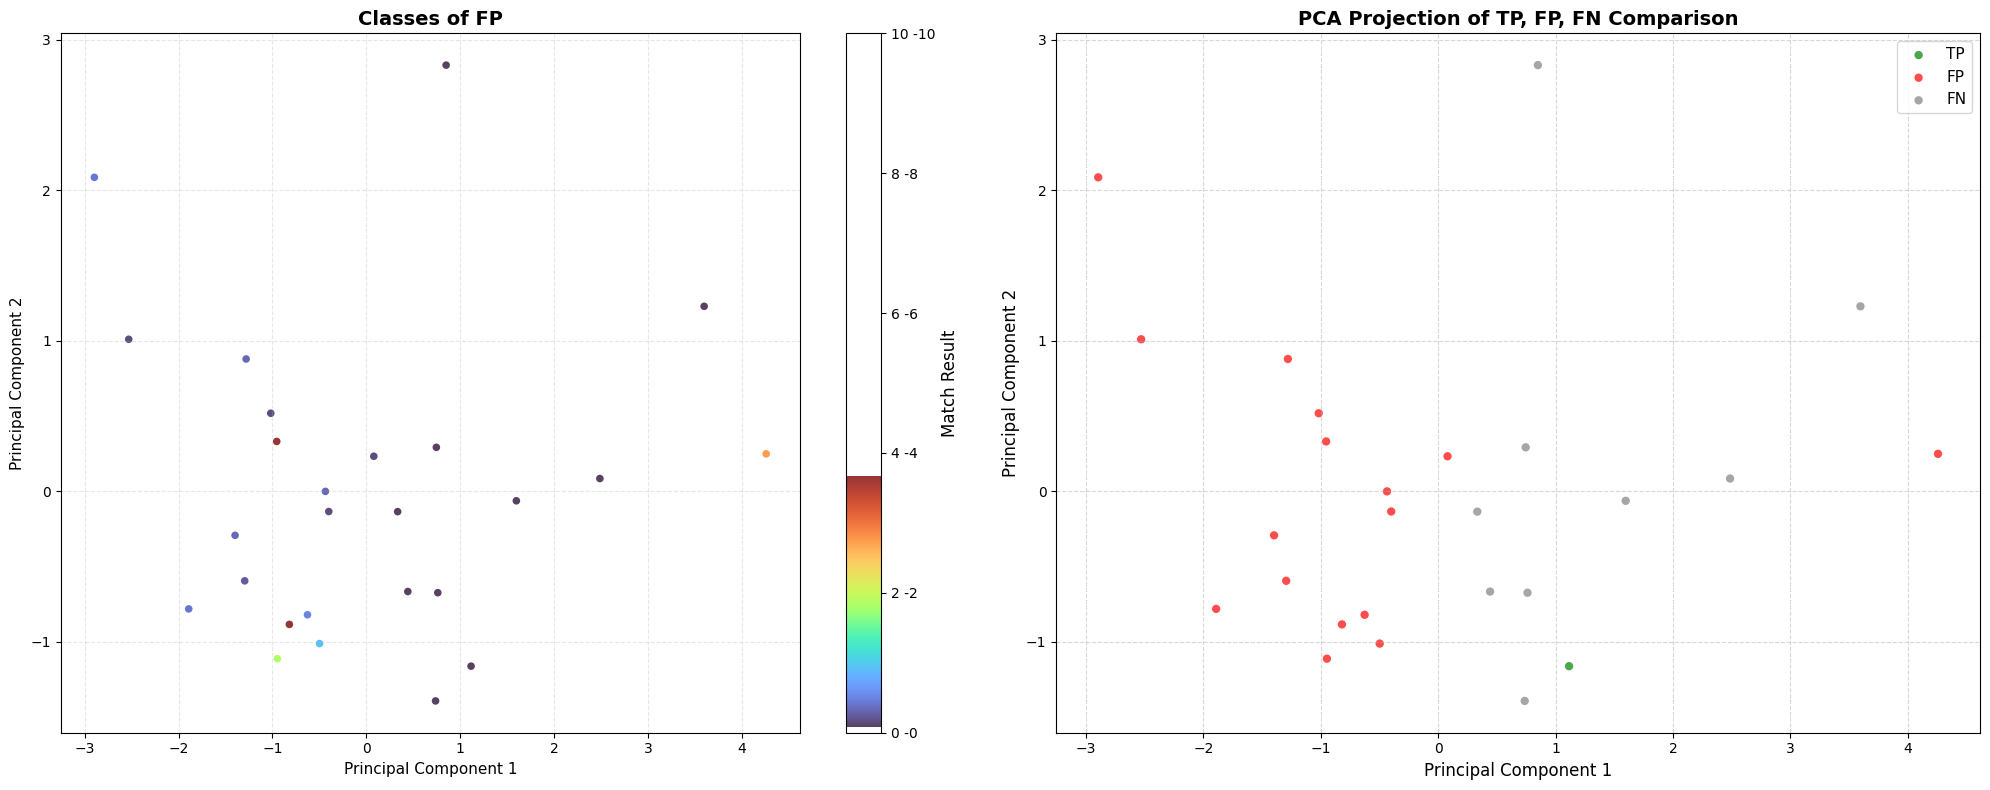

In [9]:
ErrorAnalysis.plot_comparison_fp_fn_tp_with_actual(
    TP=TP,
    FN=FN,
    FP=FP,
    all_items=TPFPFN,
    all_class_indices=all_class_indices
)